# Controlling swarms toward flocks and mills

## 1 Jurdjevic-Quinn feedback control

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 14

In [2]:
# ==================== 参数设置 ====================
C = 0.6
p = 1.5
l = 0.5
alpha = 2.0
beta = 1.5
M = max(np.sqrt(4/27*alpha**3/beta), 1)
N = 20
gamma = max(1, 1/M * np.sqrt(alpha**3/beta)) + 1
t_span = (0, 2000)
np.random.seed(42)

In [3]:
# ==================== 相互作用力 ====================
def interaction_force(positions):
    forces = np.zeros((N, 2))
    dists = pdist(positions)
    dists_matrix = squareform(dists)
    for i in range(N):
        for j in range(N):
            r = dists_matrix[i, j]
            if i==j:
                continue
            else:
                forces[i,:] += (positions[i] - positions[j]) / r * r ** (p-1) * np.exp(-(r**p) / p)
                forces[i,:] -= C*(positions[i] - positions[j]) / r * (r/l) ** (p-1) * np.exp(-((r/l)**p) / p) / l
    return forces / N

In [4]:
# ==================== 动力学方程 ====================
def dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]
    max_vel_history = [np.max(np.sqrt(np.sum(velocities ** 2, axis=1)))]
    max_force_history = [np.max(np.sqrt(np.sum(interaction_force(positions) ** 2, axis=1)))]

    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())
        speeds = np.sqrt(np.sum(velocities ** 2, axis=1))
        forces = np.sqrt(np.sum(interaction_force(positions) ** 2, axis=1))
        max_vel_history.append(np.max(speeds))
        max_force_history.append(np.max(forces))

    return pos_history, vel_history, max_vel_history, max_force_history

def JQ_dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]
    max_vel_history = [np.max(np.sqrt(np.sum(velocities ** 2, axis=1)))]
    max_force_history = [np.max(np.sqrt(np.sum(interaction_force(positions) ** 2, axis=1)))]

    for step in range(num_steps):
        speed = np.sqrt(np.sum(velocities ** 2, axis=1))
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        for i in range(N):
            if speed[i] < np.sqrt(alpha/beta) / gamma:
                acc[i] -= M * velocities[i] * gamma / np.sqrt(alpha/beta)
            elif speed[i] < np.sqrt(alpha/beta) * gamma:
                acc[i] -= M * velocities[i] / speed[i]
            elif speed[i] < 2 * np.sqrt(alpha/beta) * gamma:
                acc[i] -= M * velocities[i] / speed[i] * (2-speed[i]/np.sqrt(alpha/beta)/gamma)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())
        force = np.sqrt(np.sum(interaction_force(positions) ** 2, axis=1))
        max_vel_history.append(np.max(speed))
        max_force_history.append(np.max(force))

    return pos_history, vel_history, max_vel_history, max_force_history

In [5]:
# ==================== 初始位置和速度 ====================
positions = np.random.rand(N, 2)
velocities = np.zeros((N, 2))
Rand = np.random.rand(N) / 20
angles = 2 * np.pi * np.random.rand(N)
velocities[:, 0] = np.cos(angles) * Rand
velocities[:, 1] = np.sin(angles) * Rand

In [6]:
# ==================== 求解 ====================
dt = 0.5
num_steps = int(t_span[1] / dt)
pos_history, vel_history, max_vel_history, max_force_history = dynamics(positions, velocities, dt, num_steps)
pos_JQ, vel_JQ, max_vel_JQ, max_force_JQ = JQ_dynamics(positions, velocities, dt, num_steps)

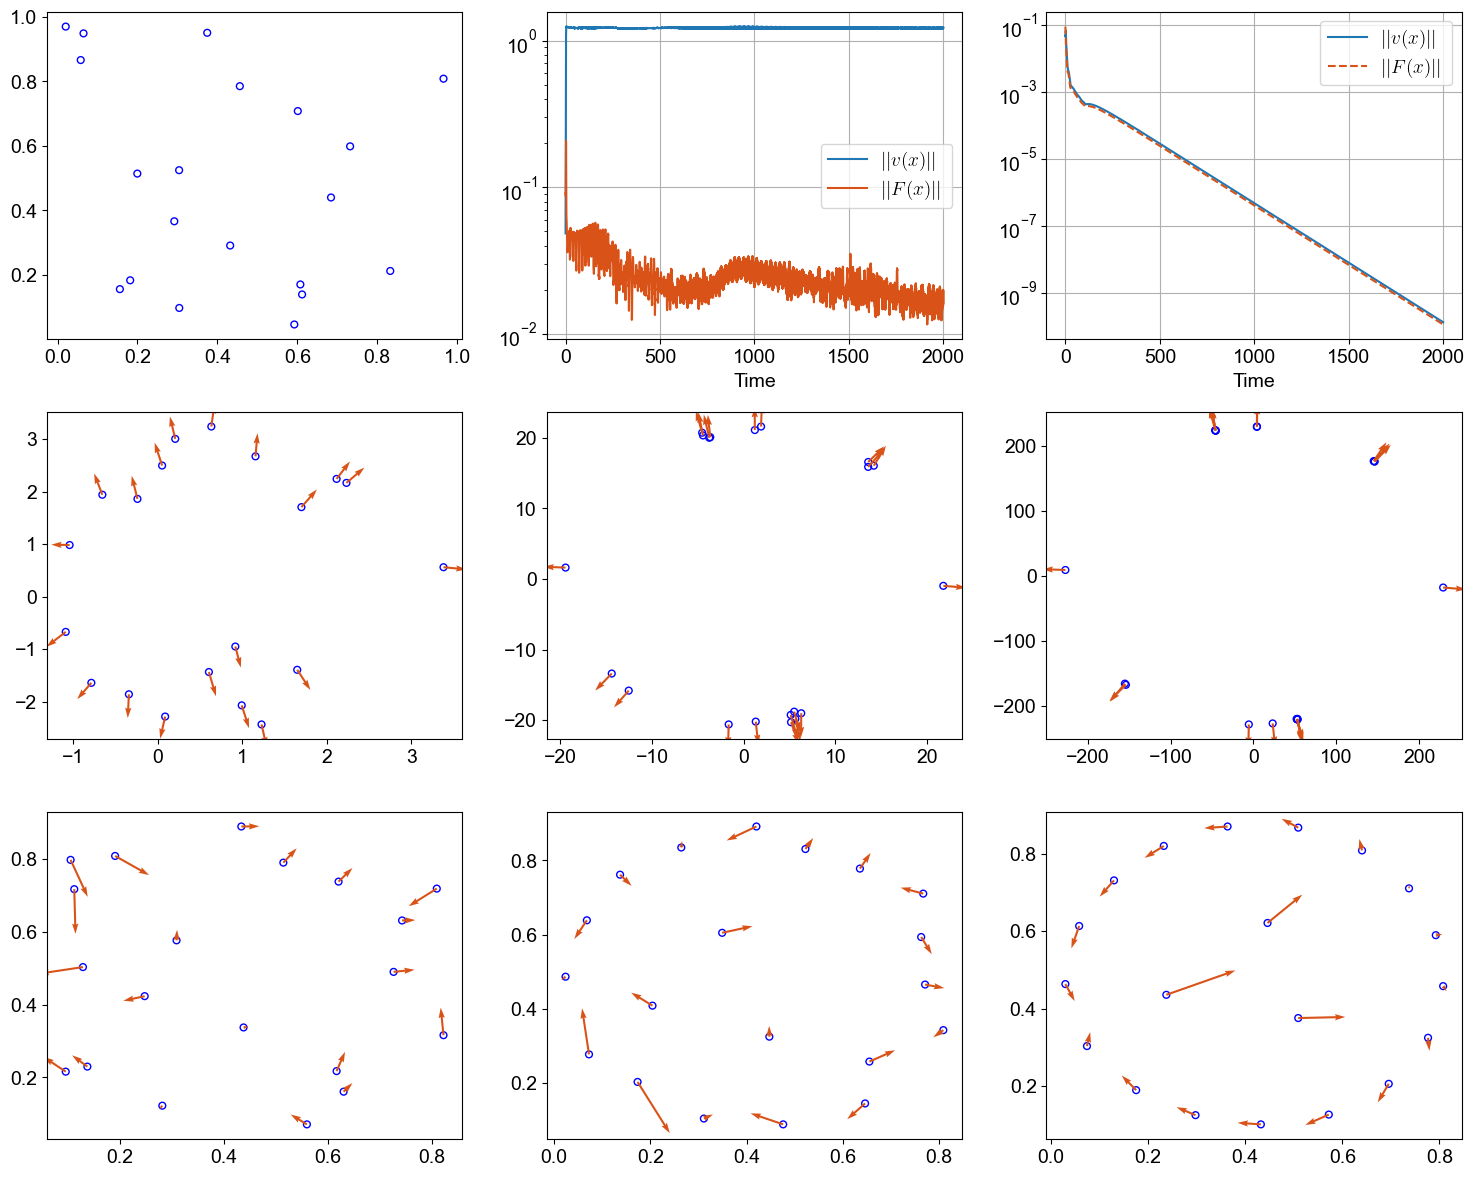

In [7]:
# ==================== 绘图 ====================
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes[0,0].scatter(positions[:, 0], positions[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
# axes[0,0].quiver(positions[:, 0], positions[:, 1], velocities[:, 0], velocities[:, 1], color='red', width=0.005)
# axes[0,0].set_title(f't = 0s')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
time_array = np.arange(0, t_span[1] + dt, dt)
axes[0,1].set_yscale('log')
axes[0,1].plot(time_array, max_vel_history, label='$||v(x)||$')
axes[0,1].plot(time_array, max_force_history, label='$||F(x)||$', color='#D95319')
axes[0,1].set_xlabel('Time')
axes[0,1].legend()
axes[0,1].grid(True)
axes[0,2].set_yscale('log')
axes[0,2].plot(time_array, max_vel_JQ, label='$||v(x)||$')
axes[0,2].plot(time_array, max_force_JQ, label='$||F(x)||$', color='#D95319', linestyle='--')
axes[0,2].set_xlabel('Time')
axes[0,2].legend()
axes[0,2].grid(True)

timestamps = [4, 20, 200]
indices = [int(t / dt) for t in timestamps]
for idx, t in enumerate(timestamps):
    ax = axes[1, idx]
    pos = pos_history[indices[idx]]
    vel = vel_history[indices[idx]]
    ax.scatter(pos[:, 0], pos[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color='#D95319', width=0.005)
for idx, t in enumerate(timestamps):
    ax = axes[2, idx]
    pos = pos_JQ[indices[idx]]
    vel = vel_JQ[indices[idx]]
    ax.scatter(pos[:, 0], pos[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color='#D95319', width=0.005)
    # ax.set_title(f't = {int(t)}s')

plt.tight_layout()
plt.show()

## 2 Flocking transition

In [8]:
# ==================== 动力学方程 ====================
def dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]

    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        theta = theta0 + (thetaT-theta0) * step / num_steps
        R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
        acc = self_force - interaction_force(positions) - M * (velocities - R @ v0)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())

    return pos_history, vel_history

In [9]:
# ==================== 初始位置和速度 ====================
theta0 = 63.4349/180*np.pi
thetaT = np.pi
v0 = np.sqrt(alpha/beta) * np.array([np.cos(theta0),np.sin(theta0)])
positions = np.zeros((N, 2))
angles = np.linspace(0, 2 * np.pi, int(N/3))
rand = np.random.rand(int(N/3)) * 0.4
positions[:int(N/3), 0] = 0.45 + np.cos(angles) * rand
positions[:int(N/3), 1] = 0.45 + np.sin(angles) * rand
angles = np.linspace(0, 2 * np.pi, N-int(N/3))
positions[int(N/3):, 0] = 0.45 + np.cos(angles) * 0.4
positions[int(N/3):, 1] = 0.45 + np.sin(angles) * 0.4
velocities = np.ones((N, 2)) * v0
pos0, vel0 = dynamics(positions, velocities, 0.5, int(t_span[1] / 0.5))
positions[:int(N/3)] = [0.45, 0.45] + pos0[-1][:int(N/3)] - np.mean(pos0[-1][int(N/3):],axis=0)

In [10]:
# ==================== 求解 ====================
dt = 0.5
t_span = (0, 200)
num_steps = int(t_span[1] / dt)
pos_history, vel_history = dynamics(positions, velocities, dt, num_steps)
mean_angles = []
for velocities in vel_history:
    angles = np.arctan2(velocities[:, 1], velocities[:, 0])
    mean_angles.append(np.mean(angles))

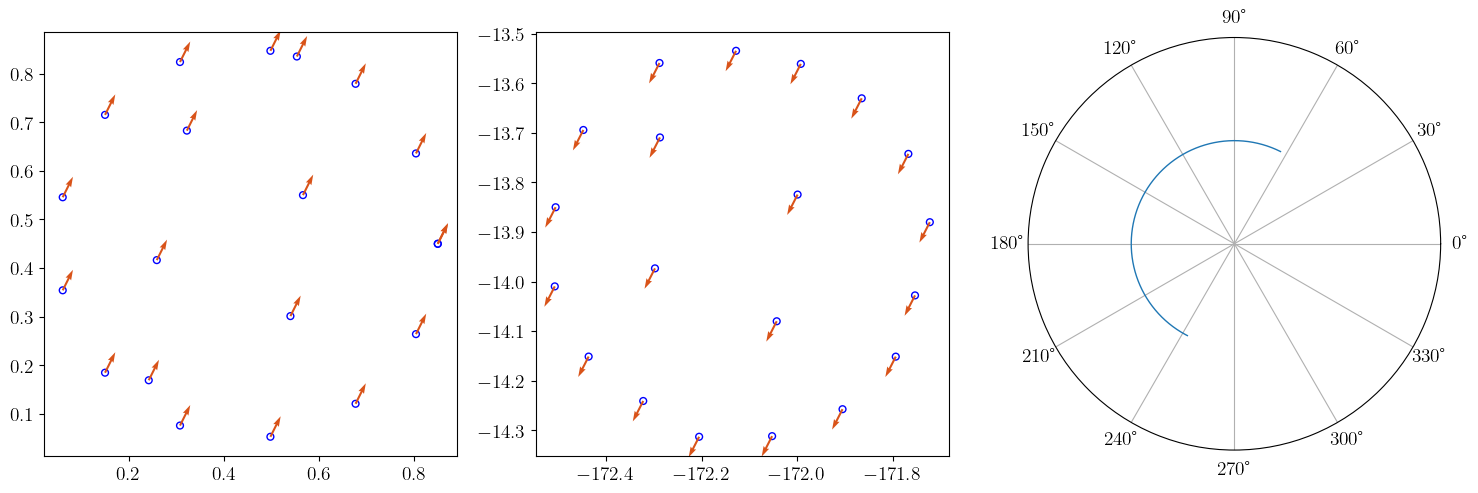

In [11]:
# ==================== 绘图 ====================
plt.figure(figsize=(15, 5))
ax1 = plt.subplot(131)
pos = pos_history[0]
vel = vel_history[0]
ax1.scatter(pos[:, 0], pos[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
ax1.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color='#D95319', width=0.005)

ax2 = plt.subplot(132)
pos = pos_history[int(200/dt)]
vel = vel_history[int(200/dt)]
ax2.scatter(pos[:, 0], pos[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
ax2.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color='#D95319', width=0.005)
r = np.ones(num_steps)*np.sqrt(alpha/beta)
theta = np.linspace(theta0, 2*np.pi+mean_angles[-1], num_steps)

ax3 = plt.subplot(133, projection='polar')
ax3.set_rgrids(np.arange(0.0, 1.5, 1.5))
ax3.set_thetagrids(np.arange(0.0, 360.0, 30.0))
ax3.plot(theta, r, linewidth=1)
ax3.grid(True)
plt.tight_layout()
plt.show()

## 3 Mill ring stability

In [12]:
# ==================== 参数设置 ====================
a = 4
b = 1
alpha = 10
beta = 3
R = 1.077918
N = 20

In [13]:
# ==================== 相互作用力 ====================
def interaction_force(positions):
    forces = np.zeros((N, 2))
    dists = pdist(positions)
    dists_matrix = squareform(dists)
    for i in range(N):
        for j in range(N):
            r = dists_matrix[i, j]
            if i==j:
                continue
            else:
                forces[i,:] += (positions[i] - positions[j]) * r ** (a-2)
                forces[i,:] -= (positions[i] - positions[j]) * r ** (b-2)
    return forces / N

In [14]:
# ==================== 动力学方程 ====================
def dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]
    max_vel_history = [np.max(np.sqrt(np.sum(velocities ** 2, axis=1)))]
    max_force_history = [np.max(np.sqrt(np.sum(interaction_force(positions) ** 2, axis=1)))]

    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())
        speeds = np.sqrt(np.sum(velocities ** 2, axis=1))
        forces = np.sqrt(np.sum(interaction_force(positions) ** 2, axis=1))
        max_vel_history.append(np.max(speeds))
        max_force_history.append(np.max(forces))

    return pos_history, vel_history, max_vel_history, max_force_history

def dynamics_copy(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]

    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())

    return pos_history

In [15]:
# ==================== 初始位置和速度 ====================
angles = np.linspace(0, 2 * np.pi, N)
positions = np.column_stack([np.cos(angles), np.sin(angles)]) / 4 * R
velocities = np.column_stack([-np.sin(angles), np.cos(angles)])

In [16]:
# ==================== 求解 ====================
dt = 0.01
pos_history, vel_history, max_vel_history, max_force_history = dynamics(positions, velocities, dt, int(50 / dt))
velocities2 = np.column_stack([-np.sin(angles), np.cos(angles)])
pos1_history= dynamics_copy(positions * 8, velocities2, dt, int(120 / dt))
pos2_history= dynamics_copy(positions * 16, velocities2, dt, int(120 / dt))
velocities3 = np.column_stack([-np.sin(angles + np.pi / 6), np.cos(angles + np.pi / 6)])
velocities4 = np.column_stack([-np.sin(angles + np.pi / 2 * 0.99), np.cos(angles + np.pi / 2 * 0.99)])
pos3_history = dynamics_copy(positions * 4, velocities3, dt, int(120 / dt))
pos4_history = dynamics_copy(positions * 4, velocities4, dt, int(120 / dt))

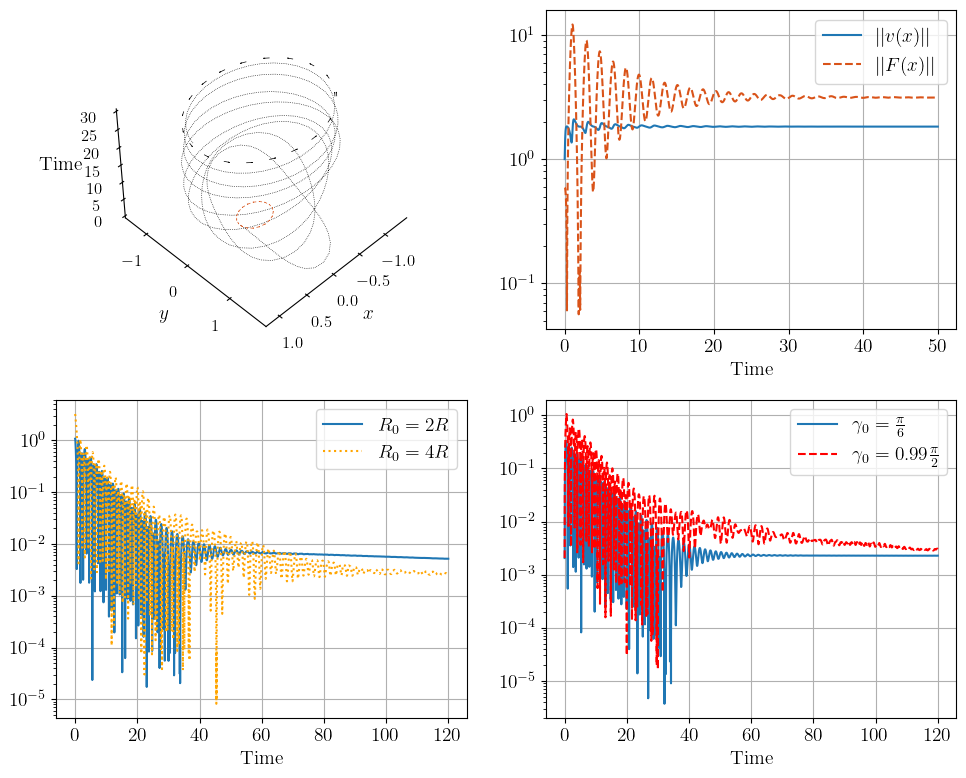

In [17]:
# ==================== 绘图 ====================
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
t_steps = np.arange(0, int(30/dt)) * dt
ax1.quiver3D(positions[:, 0], positions[:, 1], np.zeros(N),
            velocities[:, 0], velocities[:, 1], np.zeros(N), color='#D95319', length=0.05, linewidth=0.5)
ax1.quiver3D(pos_history[-1][:, 0], pos_history[-1][:, 1], np.ones(N)*30,
           vel_history[-1][:, 0], vel_history[-1][:, 1], np.zeros(N)*30, color='k', length=0.05, linewidth=0.5)
x_traj = [pos_history[step][0, 0] for step in range(0, int(30/dt), 10)]
y_traj = [pos_history[step][0, 1] for step in range(0, int(30/dt), 10)]
z_traj = t_steps[::10]
ax1.plot3D(x_traj, y_traj, z_traj, color='k', linewidth=0.5, linestyle=':')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_zlabel('Time')
ax1.tick_params(axis='both', labelsize=12)
ax1.xaxis.pane.set_alpha(0)
ax1.yaxis.pane.set_alpha(0)
ax1.zaxis.pane.set_alpha(0)
ax1.set_facecolor('none')
ax1.grid(False)
ax1.view_init(elev=45, azim=45)

ax2 = fig.add_subplot(2, 2, 2)
time_array = np.arange(0, 50 + dt, dt)
ax2.set_yscale('log')
ax2.plot(time_array[:int(50/dt)], max_vel_history[:int(50/dt)], label='$||v(x)||$')
ax2.plot(time_array[:int(50/dt)], max_force_history[:int(50/dt)],
         label='$||F(x)||$', color='#D95319', linestyle='--')
ax2.set_xlabel('Time')
ax2.legend()
ax2.grid(True)

ax3 = fig.add_subplot(2, 2, 3)
radius1 = np.zeros(int(120/dt) + 1)
radius2 = np.zeros(int(120/dt) + 1)
for t_idx in np.arange(int(120/dt) + 1):
    xm1 = pos1_history[t_idx].mean(axis=0)
    xm2 = pos2_history[t_idx].mean(axis=0)
    radius1[t_idx] = np.abs(np.mean(np.linalg.norm(pos1_history[t_idx] - xm1, axis=1)) - R)
    radius2[t_idx] = np.abs(np.mean(np.linalg.norm(pos2_history[t_idx] - xm2, axis=1)) - R)
ax3.plot(np.arange(0, 120 + dt, dt), radius1, label="$R_0=2R$")
ax3.plot(np.arange(0, 120 + dt, dt), radius2, color='orange', label="$R_0=4R$", linestyle=':')
ax3.set_xlabel('Time')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(2, 2, 4)
gamma1 = np.zeros(int(120/dt) + 1)
gamma2 = np.zeros(int(120/dt) + 1)
for t_idx in np.arange(int(120/dt) + 1):
    xm3 = pos3_history[t_idx].mean(axis=0)
    xm4 = pos4_history[t_idx].mean(axis=0)
    gamma1[t_idx] = np.abs(np.mean(np.linalg.norm(pos3_history[t_idx] - xm3, axis=1)) - R)
    gamma2[t_idx] = np.abs(np.mean(np.linalg.norm(pos4_history[t_idx] - xm4, axis=1)) - R)
ax4.plot(np.arange(0, 120 + dt, dt), gamma1, label=r"$\gamma_0=\frac{\pi}{6}$")
ax4.plot(np.arange(0, 120 + dt, dt), gamma2, color='r', label=r"$\gamma_0=0.99\frac{\pi}{2}$", linestyle='--')
ax4.set_xlabel('Time')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True)
plt.tight_layout()
plt.show()

## 4 Stabilization towards mill ring

In [18]:
# ==================== 参数设置 ====================
lambda1 = 1e-3
lambda2 = 1e-3
t_span = (0, 60)

In [19]:
# ==================== 动力学方程 ====================
def dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]
    u_history = []
    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        def obj(x):
            u = np.ones((N, 1)) * x
            v = velocities + u * dt
            p = positions + v * dt
            p_mean = p.mean(axis=0)
            obj = lambda1 * np.linalg.norm(x) * N
            obj += lambda2 * np.sum(x ** 2) * N
            obj += np.sum((np.sum((p - p_mean) ** 2,axis=1, keepdims=True) - 1.075 ** 2) ** 2)
            p_norm = np.linalg.norm(p, axis=1, keepdims=True) ** 2
            v_desired = np.sqrt(alpha / beta) * np.column_stack([-p[:, 1] / p_norm[:, 0], p[:, 0] / p_norm[:, 0]])
            obj += np.sum(np.linalg.norm(v - v_desired, axis=1))
            return obj
        res = minimize(obj, np.zeros(2), bounds=([-1, 1], [-1, 1]))
        u = res.x
        theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
        acc[:,0] += u[0] * np.cos(theta) - u[1] * np.sin(theta)
        acc[:,1] += u[0] * np.sin(theta) + u[1] * np.cos(theta)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())
        u_history.append(u)

    return pos_history, vel_history, u_history

def un_dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]
    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())

    return pos_history, vel_history

In [20]:
# ==================== 初始位置和速度 ====================
positions = np.random.rand(N, 2)*3-1
velocities = positions * np.random.rand(N, 2)

# ==================== 求解 ====================
dt = 0.01
num_steps = int(t_span[1] / dt)
pos_history, vel_history , u_history = dynamics(positions, velocities, dt, num_steps)
un_pos_history, un_vel_history = un_dynamics(positions, velocities, dt, num_steps)

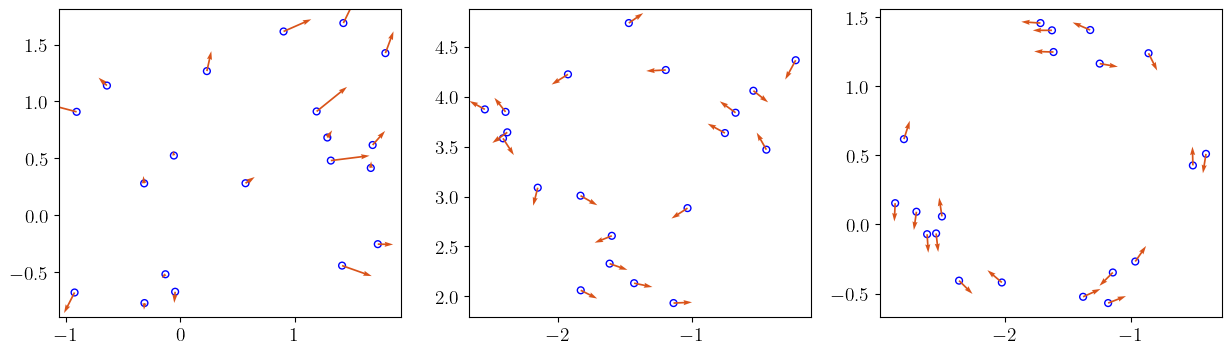

In [21]:
# ==================== 绘图 ====================
plt.figure(figsize=(15, 4))
timestamps = [0, 10, 40]
indices = [int(t / dt) for t in timestamps]
for idx, t in enumerate(timestamps):
    ax = plt.subplot(1,3,idx+1)
    pos = pos_history[indices[idx]]
    vel = vel_history[indices[idx]]
    ax.scatter(pos[:, 0], pos[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color='#D95319', width=0.005)
    # ax.set_title(f't = {int(t)}s')

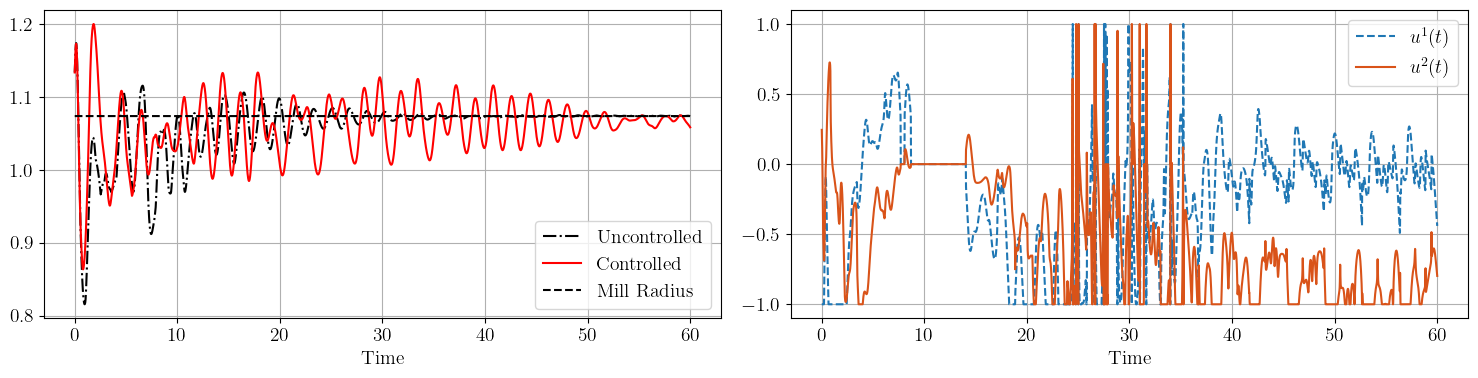

In [22]:
plt.figure(figsize=(15, 4))
ax = plt.subplot(1,2,1)
t_history = np.linspace(0, 60, num_steps+1)
config_radius = np.zeros_like(t_history)
un_config_radius = np.zeros_like(t_history)
for t_idx in np.arange(num_steps+1):
    xm = pos_history[t_idx].mean(axis=0)
    config_radius[t_idx] = np.mean(np.linalg.norm(pos_history[t_idx] - xm, axis=1))
    un_xm = un_pos_history[t_idx].mean(axis=0)
    un_config_radius[t_idx] = np.mean(np.linalg.norm(un_pos_history[t_idx] - un_xm, axis=1))
ax.plot(t_history, un_config_radius, color='k', linestyle='-.', label="Uncontrolled")
ax.plot(t_history, config_radius, color='r', label="Controlled")
ax.plot(t_history, un_config_radius[-1]*np.ones_like(t_history), color='k', label="Mill Radius", linestyle='--')
ax.set_xlabel("Time")
ax.legend()
ax.grid()

ax = plt.subplot(1,2,2)
t_history = np.linspace(0, 60, num_steps)
ax.plot(t_history, np.array(u_history)[:, 0], label='$u^1(t)$', linestyle='--')
ax.plot(t_history, np.array(u_history)[:, 1], label='$u^2(t)$', color='#D95319')
ax.set_xlabel("Time")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## 5 Mill to flock transition

In [23]:
# ==================== 参数设置 ====================
Lambda = 1e-3
t_span = (0, 40)

In [24]:
# ==================== 动力学方程 ====================
def dynamics(positions, velocities, dt, num_steps):
    pos_history = [positions.copy()]
    vel_history = [velocities.copy()]
    u_history = []
    for step in range(num_steps):
        speed_sq = np.sum(velocities ** 2, axis=1, keepdims=True)
        self_force = (alpha - beta * speed_sq) * velocities
        acc = self_force - interaction_force(positions)
        def obj(x):
            u = np.ones((N, 1)) * x
            v = velocities + u * dt
            p = positions + v * dt
            p_mean = p.mean(axis=0)
            obj = Lambda * np.sum(x ** 2) * N
            obj += np.sum((np.sum((p - p_mean) ** 2,axis=1, keepdims=True) - 0.6 ** 2) ** 2)
            obj += np.sum((v - np.array([np.sqrt(alpha/beta), 0])) ** 2)
            return obj
        res = minimize(obj, np.zeros(2), bounds=([-1,1],[-1,1]))
        u = res.x
        acc += np.ones((N, 1)) * u
        velocities = velocities + acc * dt
        positions = positions + velocities * dt
        pos_history.append(positions.copy())
        vel_history.append(velocities.copy())
        u_history.append(u)

    return pos_history, vel_history, u_history

In [25]:
# ==================== 初始位置和速度 ====================
positions = np.zeros((N, 2))
velocities = np.zeros((N, 2))
angles = np.linspace(0, 2 * np.pi, N)
positions[:, 0] = np.cos(angles)
positions[:, 1] = np.sin(angles)
velocities[:, 0] = -np.sin(angles)
velocities[:, 1] = np.cos(angles)

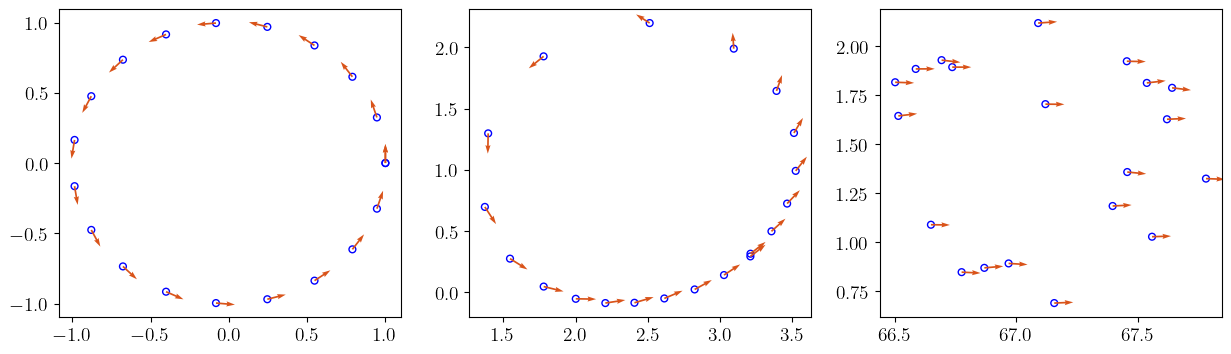

In [26]:
# ==================== 求解 ====================
dt = 0.01
num_steps = int(t_span[1] / dt)
pos_history, vel_history , u_history = dynamics(positions, velocities, dt, num_steps)
# ==================== 绘图 ====================
plt.figure(figsize=(15, 4))
timestamps = [0, 4, 40]
indices = [int(t / dt) for t in timestamps]
for idx, t in enumerate(timestamps):
    ax = plt.subplot(1,3,idx+1)
    pos = pos_history[indices[idx]]
    vel = vel_history[indices[idx]]
    ax.scatter(pos[:, 0], pos[:, 1], marker='o', facecolors='none', edgecolors='b', s=24)
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color='#D95319', width=0.005)
    # ax.set_title(f't = {int(t)}s')

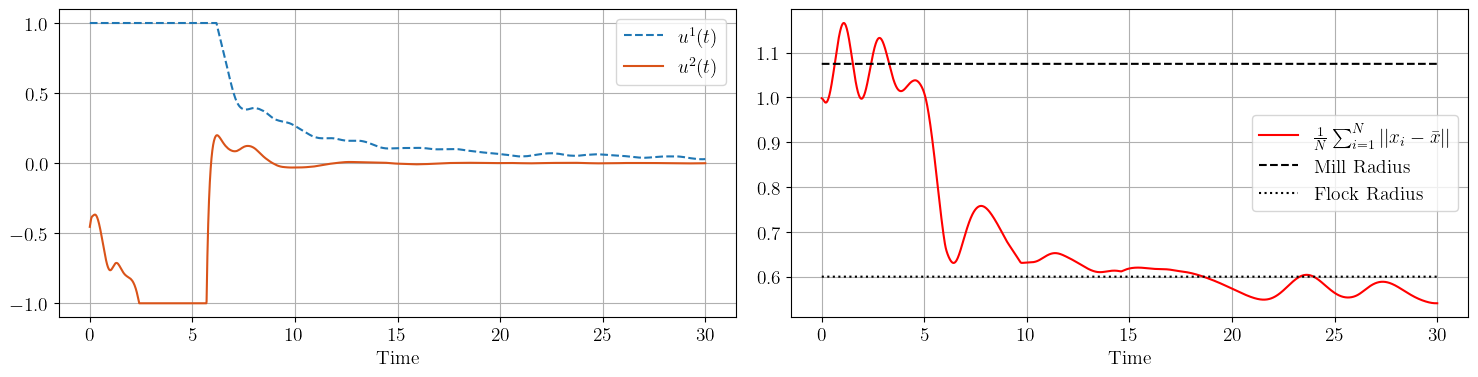

In [27]:
plt.figure(figsize=(15, 4))
ax = plt.subplot(1,2,1)
t_history = np.linspace(0, 30, int(30/dt))
ax.plot(t_history, np.array(u_history)[:int(30/dt), 0], label='$u^1(t)$', linestyle='--')
ax.plot(t_history, np.array(u_history)[:int(30/dt), 1], label='$u^2(t)$', color='#D95319')
ax.set_xlabel("Time")
ax.legend()
ax.grid()

ax = plt.subplot(1,2,2)
config_radius = np.zeros_like(t_history)
for t_idx in np.arange(int(30/dt)):
    xm = pos_history[t_idx].mean(axis=0)
    config_radius[t_idx] = np.mean(np.linalg.norm(pos_history[t_idx] - xm, axis=1))
ax.plot(t_history, config_radius[:int(30/dt)], color='r', label=r"$\frac{1}{N}\sum_{i=1}^{N}||x_i-\bar{x}||$")
ax.plot(t_history, 1.075*np.ones_like(t_history), color='k', label=r"$\rm{Mill\ Radius}$", linestyle='--')
ax.plot(t_history, 0.6*np.ones_like(t_history), color='k', linestyle=':', label=r"$\rm{Flock\ Radius}$")
ax.set_xlabel("Time")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()